In [ ]:
from sklearn import ensemble
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_text
from sklearn.tree import plot_tree

In [ ]:


from sklearn import model_selection
from sklearn import preprocessing
from sklearn import metrics



In [ ]:
ctrain=pd.read_csv('train.csv',index_col=0)
train=pd.DataFrame(ctrain)
ctest=pd.read_csv('test.csv',index_col=0)
test=pd.DataFrame(ctest)
train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
train.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


In [ ]:
test.isnull().sum()

,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327
Embarked,0


In [ ]:
train.shape

(891, 11)

In [ ]:
train.describe()
train.dtypes

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


In [ ]:
train=train.drop(['Name','Cabin','Ticket'],axis=1)
test=test.drop(['Name','Cabin','Ticket'],axis=1)

In [ ]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S


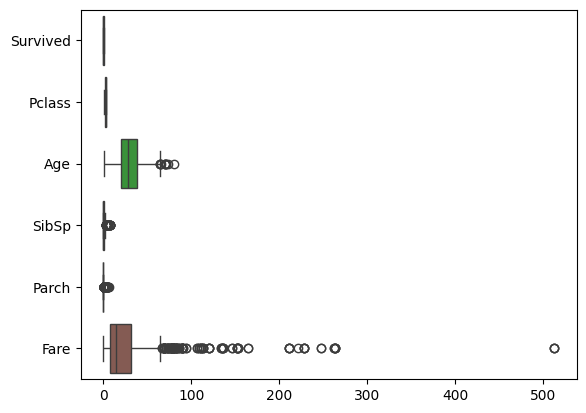

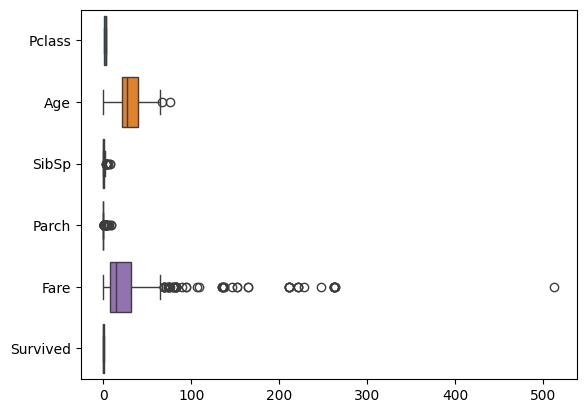

In [ ]:
plt.figure()
sns.boxplot(data=train, orient='h')
plt.show()
plt.figure()
sns.boxplot(data=test, orient='h')
plt.show()

In [ ]:
df=train
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier range
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]

biggest_outlier = outliers['Fare'].max()
smallest_outlier = outliers['Fare'].min()
print("Biggest outlier:", biggest_outlier, smallest_outlier)

smallest=df['Fare'].min()
print(smallest)

Biggest outlier: 512.3292 66.6
0.0


In [ ]:
train = train[train['Fare'] < 500]

<ipython-input-15-5ad95cb786b3>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Fare'], rug=True)


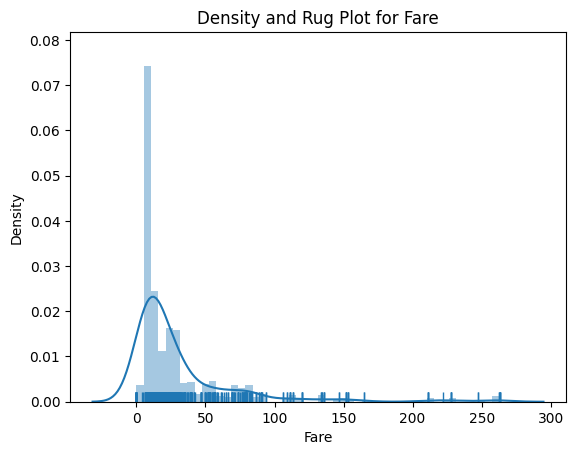

In [ ]:
plt.figure()
sns.distplot(train['Fare'], rug=True)
plt.title('Density and Rug Plot for Fare')
plt.show()

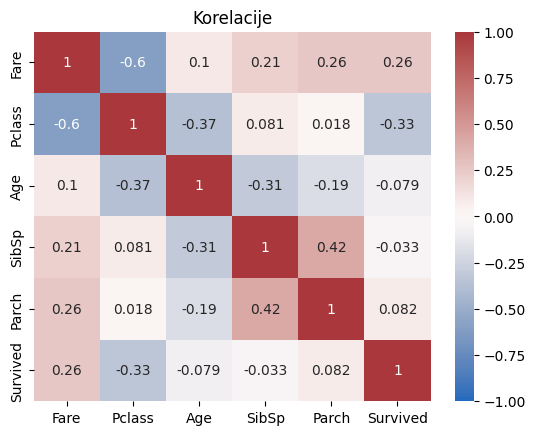

In [ ]:
corr = train[['Fare','Pclass','Age','SibSp','Parch','Survived']].corr()
sns.heatmap(corr, annot=True, cmap='vlag', vmin=-1, vmax=1)
plt.title('Korelacije')
plt.show()

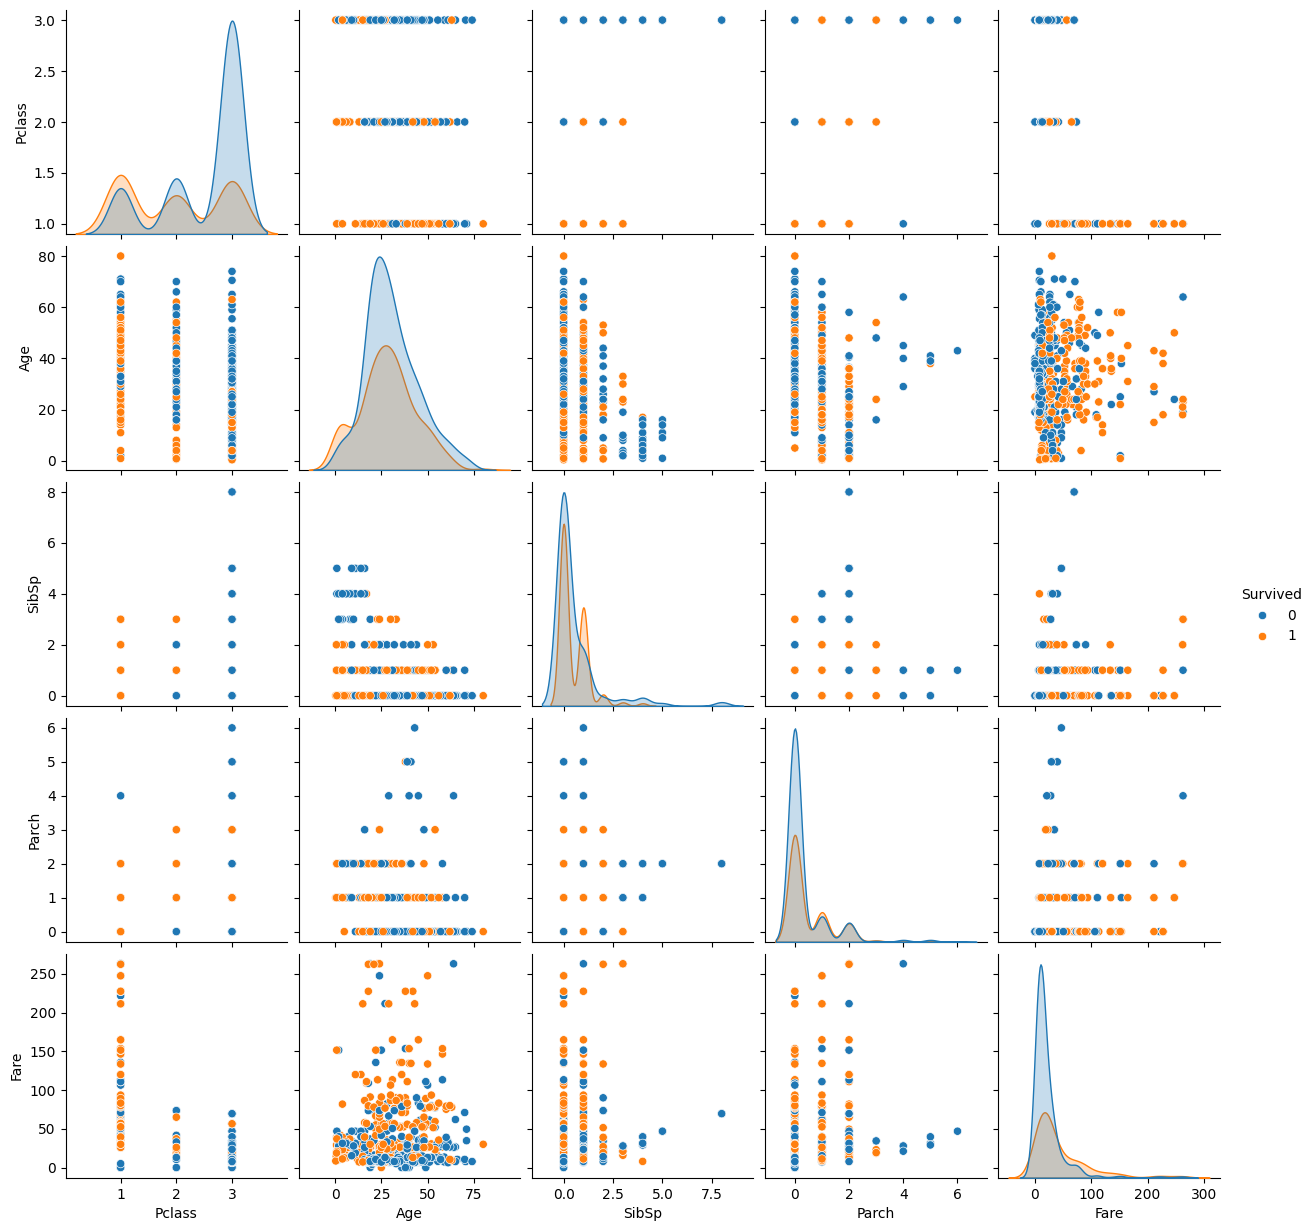

In [ ]:
sns.pairplot(train, hue='Survived')
plt.show()

In [ ]:
train.head()
train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,S
888,1,1,female,19.0,0,0,30.0000,S
889,0,3,female,NaN,1,2,23.4500,S


In [ ]:
train['Sex'] = train['Sex'].map( {'female': 1, 'male': 0} ).astype(int)
test['Sex'] = test['Sex'].map( {'female': 1, 'male': 0} ).astype(int)

freq_port = train.Embarked.dropna().mode()[0]
#for dataset in combine:
train['Embarked'] = train['Embarked'].fillna(freq_port)
test['Fare'].fillna(test['Fare'].dropna().median(), inplace=True)


train.isnull().sum()

<ipython-input-19-8a5d1344a599>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Sex'] = train['Sex'].map( {'female': 1, 'male': 0} ).astype(int)
<ipython-input-19-8a5d1344a599>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Embarked'] = train['Embarked'].fillna(freq_port)
<ipython-input-19-8a5d1344a599>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace meth

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
print(freq_port)

S


In [ ]:
train['Embarked'] = train['Embarked'].map( {'Q':2,'S': 1, 'C': 0} ).astype(int)
test['Embarked'] = test['Embarked'].map( {'Q':2,'S': 1, 'C': 0} ).astype(int)
train.head()

<ipython-input-21-9fbb842f572a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Embarked'] = train['Embarked'].map( {'Q':2,'S': 1, 'C': 0} ).astype(int)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,1
2,1,1,1,38.0,1,0,71.2833,0
3,1,3,1,26.0,0,0,7.9250,1
4,1,1,1,35.0,1,0,53.1000,1
5,0,3,0,35.0,0,0,8.0500,1


In [ ]:
guess_ages = np.zeros((2,3))
guess_ages

array([[0., 0., 0.],
       [0., 0., 0.]])

In [ ]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,1
2,1,1,1,38.0,1,0,71.2833,0
3,1,3,1,26.0,0,0,7.9250,1
4,1,1,1,35.0,1,0,53.1000,1
5,0,3,0,35.0,0,0,8.0500,1


In [ ]:
combine=[train,test]
for dataset in combine:
    for i in range(0, 2):
        for j in range(0, 3):
            guess_df = dataset[(dataset['Sex'] == i) & \
                                  (dataset['Pclass'] == j+1)]['Age'].dropna()

            age_guess = guess_df.median()
            guess_ages[i,j] = age_guess

    for i in range(0, 2):
        for j in range(0, 3):
            dataset.loc[(dataset['Age'].isnull()) & (dataset['Sex'] == i) & (dataset['Pclass'] == j+1),'Age'] = guess_ages[i,j]

    dataset['Age'] = dataset['Age'].astype(int)

train.head()

<ipython-input-24-1563827f58ec>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Age'] = dataset['Age'].astype(int)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,0,22,1,0,7.2500,1
2,1,1,1,38,1,0,71.2833,0
3,1,3,1,26,0,0,7.9250,1
4,1,1,1,35,1,0,53.1000,1
5,0,3,0,35,0,0,8.0500,1


In [ ]:
train['AgeBand'] = pd.cut(train['Age'], 5)

combine=[train,test]
for dataset in combine:
    dataset.loc[ dataset['Age'] <= 16, 'Age'] = 0
    dataset.loc[(dataset['Age'] > 16) & (dataset['Age'] <= 32), 'Age'] = 1
    dataset.loc[(dataset['Age'] > 32) & (dataset['Age'] <= 48), 'Age'] = 2
    dataset.loc[(dataset['Age'] > 48) & (dataset['Age'] <= 64), 'Age'] = 3
    dataset.loc[ dataset['Age'] > 64, 'Age']

train = train.drop(['AgeBand'], axis=1)
train.head()

<ipython-input-25-5c06bb55fe45>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['AgeBand'] = pd.cut(train['Age'], 5)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,0,1,1,0,7.2500,1
2,1,1,1,2,1,0,71.2833,0
3,1,3,1,1,0,0,7.9250,1
4,1,1,1,2,1,0,53.1000,1
5,0,3,0,2,0,0,8.0500,1


In [ ]:
train['FareBand'] = pd.cut(train['Fare'], 5)
train['FareBand'].unique()


[(-0.263, 52.6], (52.6, 105.2], (210.4, 263.0], (105.2, 157.8], (157.8, 210.4]]
Categories (5, interval[float64, right]): [(-0.263, 52.6] < (52.6, 105.2] < (105.2, 157.8] <
                                           (157.8, 210.4] < (210.4, 263.0]]

In [ ]:

combine=[train,test]
for dataset in combine:
    dataset.loc[ dataset['Fare'] <= 53, 'Fare'] = 0
    dataset.loc[(dataset['Fare'] > 53) & (dataset['Fare'] <= 105), 'Fare'] = 1
    dataset.loc[(dataset['Fare'] > 105) & (dataset['Fare'] <= 158), 'Fare'] = 2
    dataset.loc[(dataset['Fare'] > 158) & (dataset['Fare'] <= 210), 'Fare'] = 3
    dataset.loc[ dataset['Fare'] > 210, 'Fare']

train = train.drop(['FareBand'], axis=1)
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,0,1,1,0,0.0,1
2,1,1,1,2,1,0,1.0,0
3,1,3,1,1,0,0,0.0,1
4,1,1,1,2,1,0,1.0,1
5,0,3,0,2,0,0,0.0,1


In [ ]:
combine=[train,test]
for dataset in combine:
    dataset['Family']=dataset['SibSp']+dataset['Parch']
    dataset=dataset.drop(['SibSp','Parch'],axis=1,inplace=True)
train.head()
test.head()

,Pclass,Sex,Age,Fare,Embarked,Survived,Family
PassengerId,,,,,,,
892,3,0,2,0.0,2,0,0
893,3,1,2,0.0,1,1,1
894,2,0,3,0.0,2,0,0
895,3,0,1,0.0,1,0,0
896,3,1,1,0.0,1,1,2


In [ ]:
X_train = train.drop('Survived', axis=1)  # Features
y_train = train['Survived']
X_test = test.drop('Survived', axis=1)  # Features
y_test = test['Survived']

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [ ]:
model_forest = ensemble.RandomForestClassifier(n_estimators=70, max_depth=7, random_state=34)
scores = cross_val_score(model_forest, X_train, y_train, cv=5, scoring='accuracy')

# Print individual fold scores and mean accuracy
print("Cross-validation scores:", scores)
print("Average CV accuracy:", scores.mean())

Cross-validation scores: [0.78651685 0.82022472 0.8258427  0.79661017 0.84180791]
Average CV accuracy: 0.8142004697517933


In [ ]:
model_forest.fit(X_train, y_train)

y_predicted = model_forest.predict(X_train)

metrics.accuracy_score(y_train, y_predicted)

0.8592342342342343

In [ ]:
y_predictedts = model_forest.predict(X_test)

metrics.accuracy_score(y_test, y_predictedts)

0.84688995215311

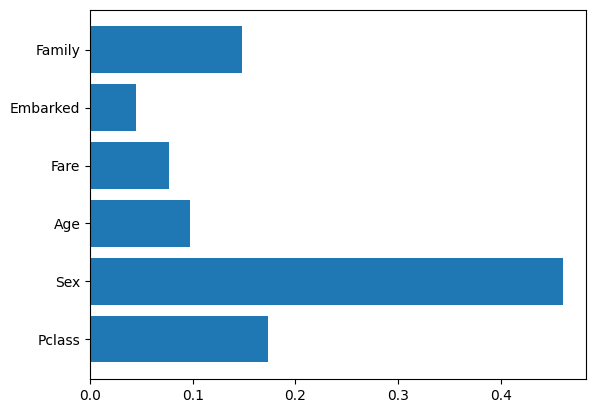

In [ ]:
plt.barh(list(X_train.columns), model_forest.feature_importances_)
plt.show()